<a href="https://colab.research.google.com/github/2025-F-CS6220/project-great-team/blob/visualization/Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

# Load your CSV file (make sure data.csv is uploaded to Colab or use the correct path)
df = pd.read_csv("data.csv")

# Drop unused or empty columns (this dataset includes an all-NaN column)
df = df.drop(columns=["Unnamed: 32"], errors="ignore")

# Preview the dataset
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


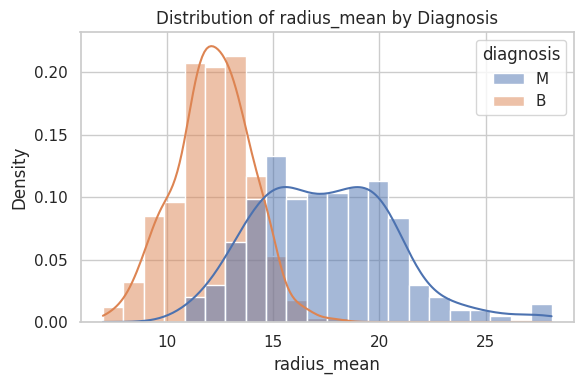

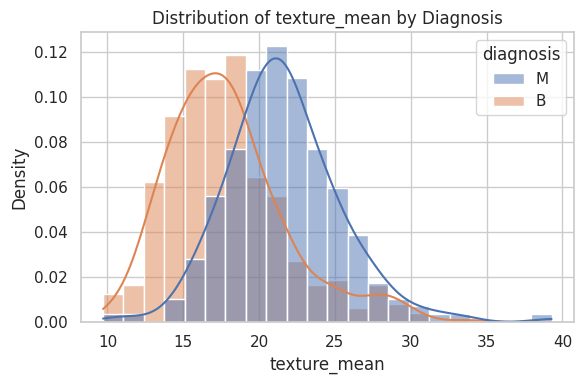

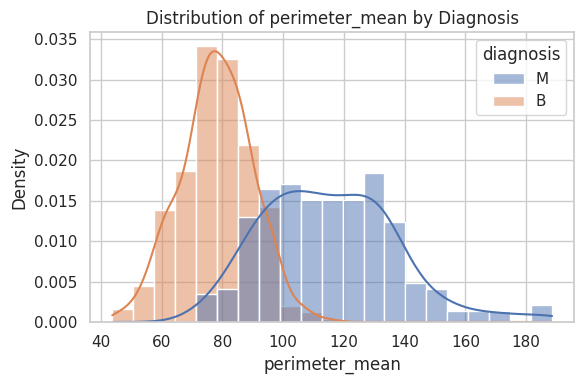

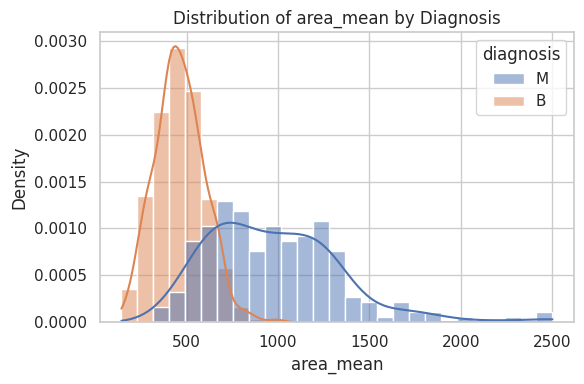

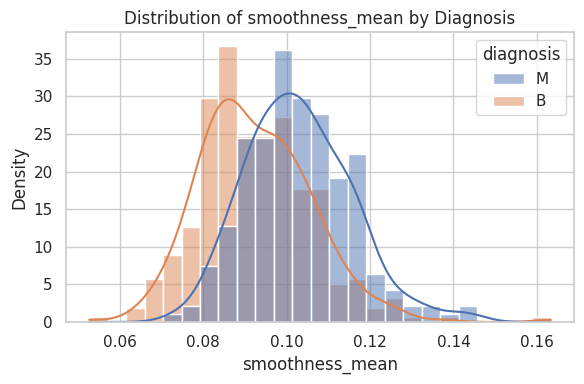

In [7]:
# Distribution plots
# Select several representative features for distribution visualization
features_for_dist = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean"
]

for feature in features_for_dist:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df,
        x=feature,
        hue="diagnosis",       # M or B
        kde=True,
        stat="density",
        common_norm=False,
        alpha=0.5
    )
    plt.title(f"Distribution of {feature} by Diagnosis")
    plt.tight_layout()
    plt.show()


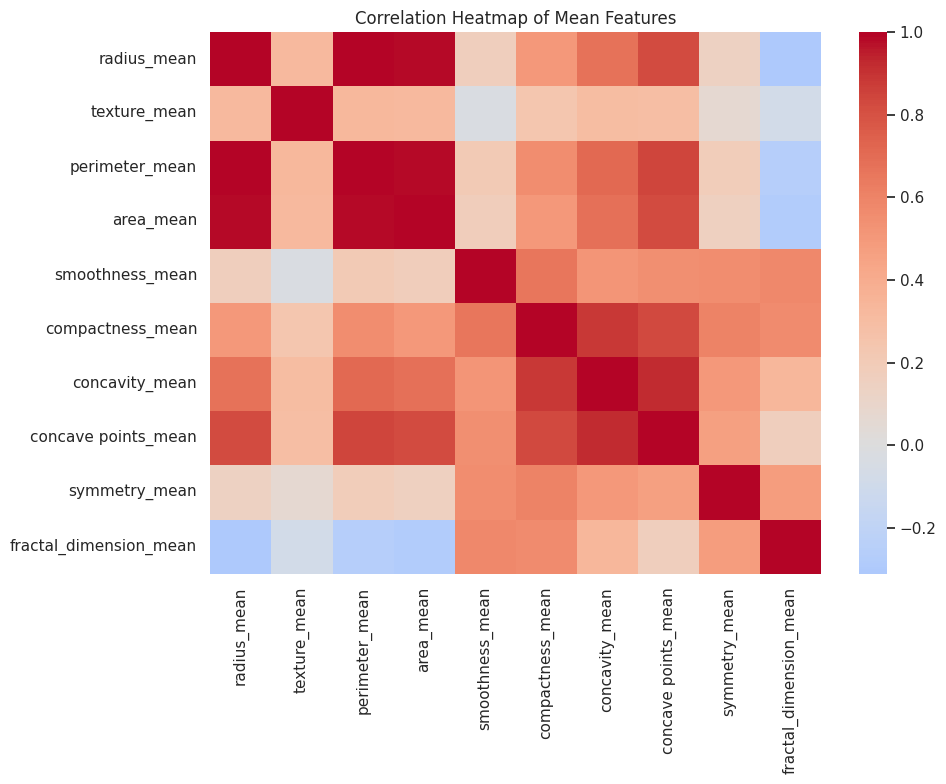

In [8]:
# Correlation heatmap
# Select only features ending with "_mean" to simplify visualization
mean_features = [col for col in df.columns if col.endswith("_mean")]

corr = df[mean_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Mean Features")
plt.tight_layout()
plt.show()

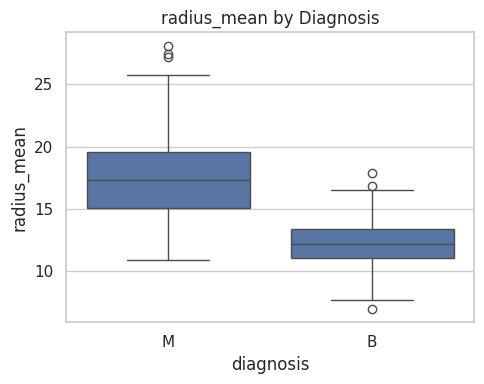

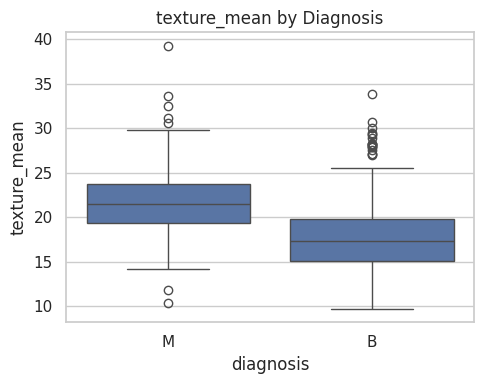

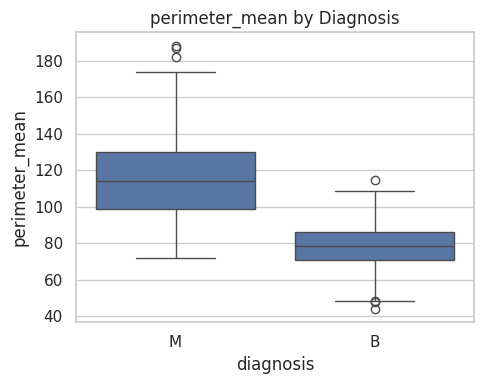

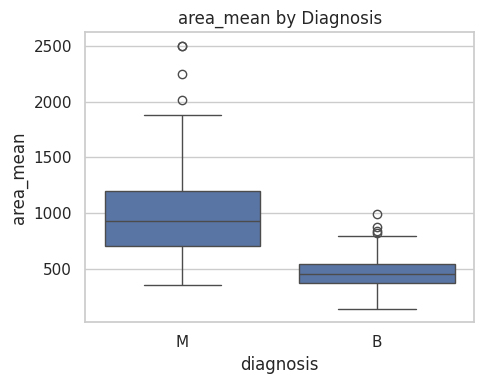

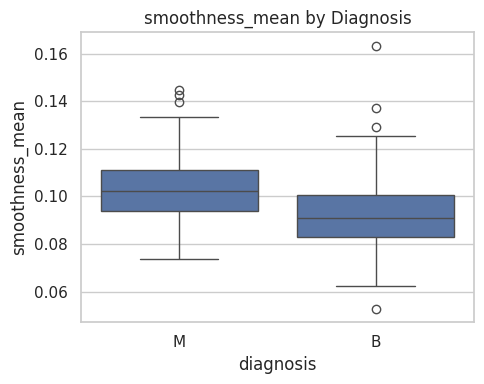

In [4]:
# Boxplots (Malignant vs Benign)
features_for_box = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean"
]

for feature in features_for_box:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df, x="diagnosis", y=feature)
    plt.title(f"{feature} by Diagnosis")
    plt.tight_layout()
    plt.show()


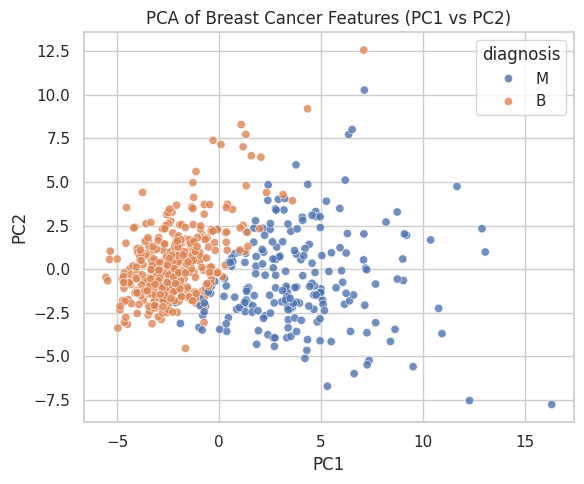

Explained variance ratio: [0.44272026 0.18971182]
Total explained variance (first 2 PCs): 0.6324320765155944


In [9]:
# PCA visualization
# Select numeric features (exclude ID)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "id" in numeric_cols:
    numeric_cols.remove("id")

X = df[numeric_cols]
y = df["diagnosis"]  # M / B

# Standardize the features for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA and reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for visualization
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["diagnosis"] = y

# Scatter plot of the first two principal components
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="diagnosis",
    alpha=0.8
)
plt.title("PCA of Breast Cancer Features (PC1 vs PC2)")
plt.tight_layout()
plt.show()

# Print explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance (first 2 PCs):", pca.explained_variance_ratio_.sum())


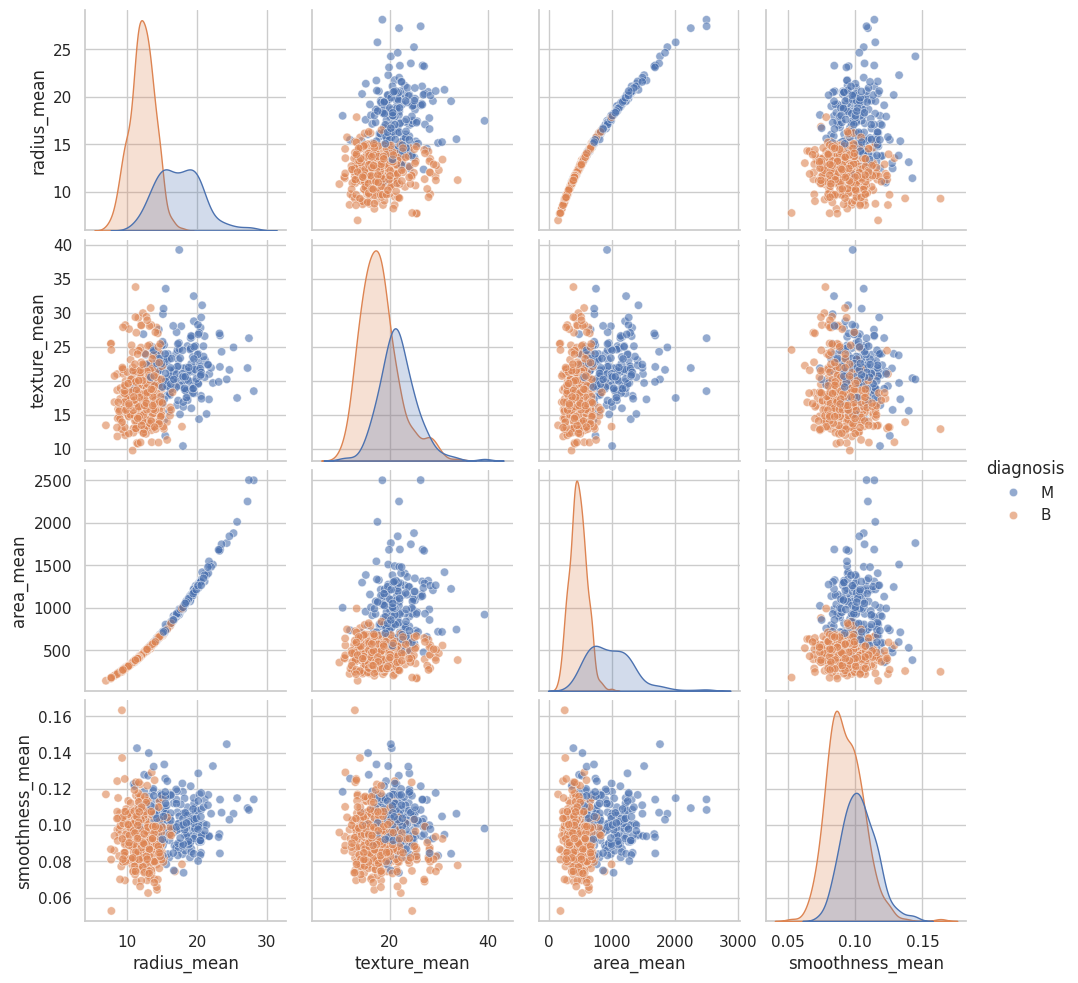

In [10]:
# Pairplot
import seaborn as sns

sns.pairplot(df[["radius_mean", "texture_mean", "area_mean", "smoothness_mean", "diagnosis"]],
             hue="diagnosis",
             diag_kind="kde",
             plot_kws={'alpha':0.6})
plt.show()


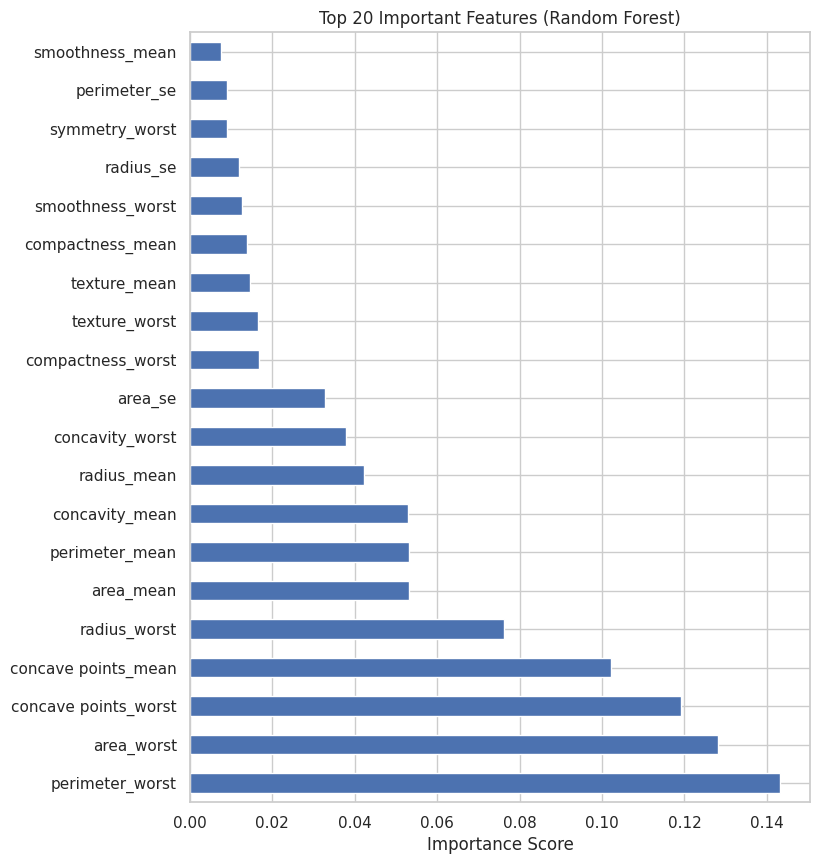

In [11]:
# Feature Importance Ranking
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, df["diagnosis"])

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
importances[:20].plot(kind='barh')
plt.title("Top 20 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.show()


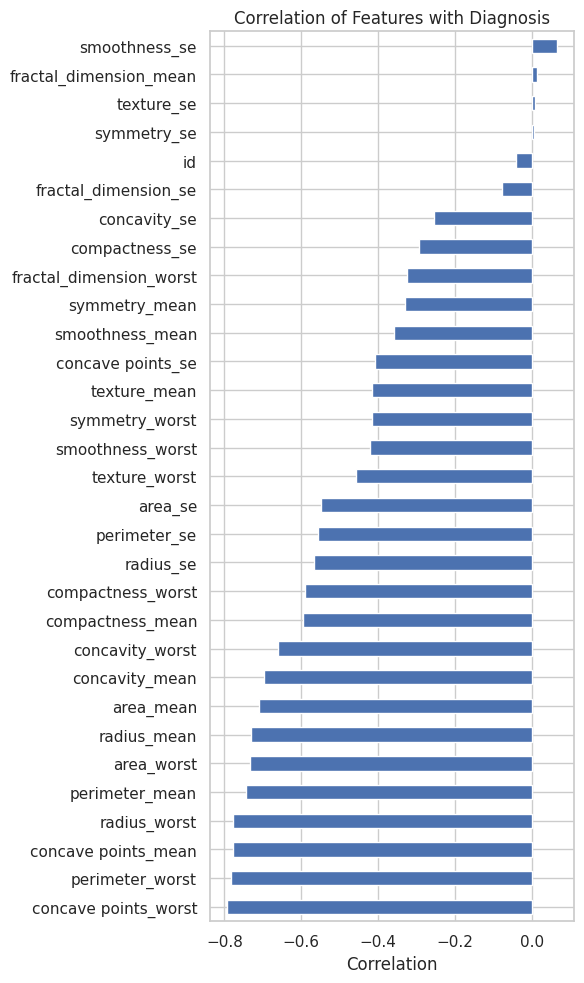

In [13]:
# Correlation with Target
# Add numeric diagnosis column
df["diagnosis_num"] = df["diagnosis"].map({"M": 0, "B": 1})

# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Compute correlation only on numeric columns
corr_numeric = df[numeric_cols].corr()

# Extract correlation with the target
corr_target = corr_numeric["diagnosis_num"].drop("diagnosis_num").sort_values()

plt.figure(figsize=(6, 10))
corr_target.plot(kind='barh')
plt.title("Correlation of Features with Diagnosis")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()